# Customer Churn Analysis

Reproduces the "Summary Page Blueprint" walkthrough:
- KPI row: Total Customers, New Joiners, Total Churn, Churn Rate
- Breakdowns: Gender, Age, Geographic, Services, Payment Method & Contract, Tenure, Churn Distribution

Brand colors used for charts: `#4A44F2` (primary), `#9B9FF2` (secondary), `#F2F2F2` (background)


In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import matplotlib.pyplot as plt
from churn_analysis import (
    load_data, kpi_summary, churn_by_gender, churn_by_age_band,
    churn_by_state, churn_by_payment_method, churn_by_tenure_band,
    churn_distribution, services_summary,
)

PRIMARY = "#4A44F2"
SECONDARY = "#9B9FF2"
BG = "#F2F2F2"
plt.rcParams["figure.facecolor"] = BG
plt.rcParams["axes.facecolor"] = BG


In [2]:
df = load_data()
df.head()

,Customer_ID,Gender,Age,Married,State,Number_of_Referrals,Tenure_in_Months,Value_Deal,Phone_Service,Multiple_Lines,Payment_Method,Monthly_Charge,Total_Refunds,Extra_Data_Charges,Total_Long_Distance_Charges,Total_Revenue,Customer_Status,Churn_Category,Churn_Reason
0,100000-F26,Male,39,No,Tamil Nadu,5,23,Deal 2,Yes,Yes,Bank Withdrawal,64.64,2.84,28.66,111.83,1614.42,Churned,Other,Moved
1,100001-E56,Male,35,Yes,California,8,49,Deal 4,Yes,Yes,Credit Card,64.11,6.52,1.38,198.64,2903.61,Stayed,Others,Others
2,100002-D10,Male,70,No,Texas,7,24,Deal 1,Yes,Yes,Mailed Check,59.41,25.28,10.03,626.26,1487.28,Joined,Others,Others
3,100003-B77,Female,35,No,West Bengal,6,25,Deal 4,No,NaN,Mailed Check,114.24,2.54,44.49,437.59,2303.88,Churned,Other,Other
4,100004-B26,Male,22,Yes,California,10,39,Deal 4,Yes,Yes,Bank Withdrawal,53.63,28.49,13.09,41.38,2292.98,Stayed,Others,Others


## KPI Row

In [3]:
kpis = kpi_summary(df)
for k, v in kpis.items():
    print(f"{k}: {v}")

Total Customers: 2000
New Joiners: 313
Total Churn: 394
Churn Rate (%): 19.7


## Churn by Gender

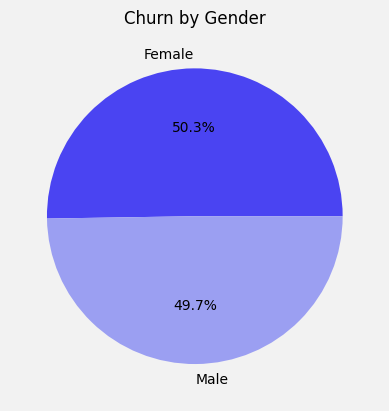

In [4]:
g = churn_by_gender(df)
g.plot(kind="pie", y="Churned_Customers", labels=g["Gender"], autopct='%1.1f%%',
       colors=[PRIMARY, SECONDARY], legend=False, ylabel="")
plt.title("Churn by Gender")
plt.show()

## Churn by Age Band

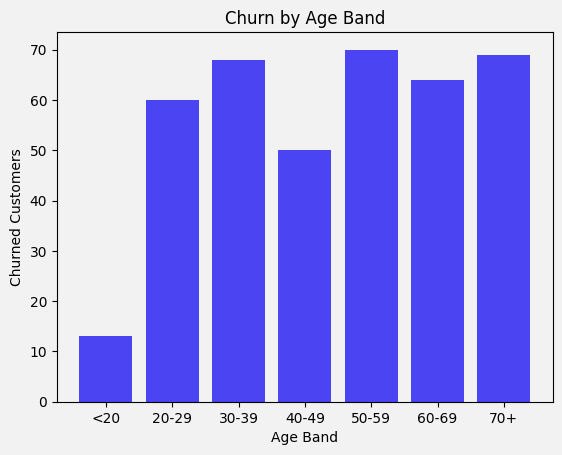

In [5]:
a = churn_by_age_band(df)
plt.bar(a["Age_Band"].astype(str), a["Churned_Customers"], color=PRIMARY)
plt.title("Churn by Age Band")
plt.xlabel("Age Band"); plt.ylabel("Churned Customers")
plt.show()

## Churn by Geographic (State)

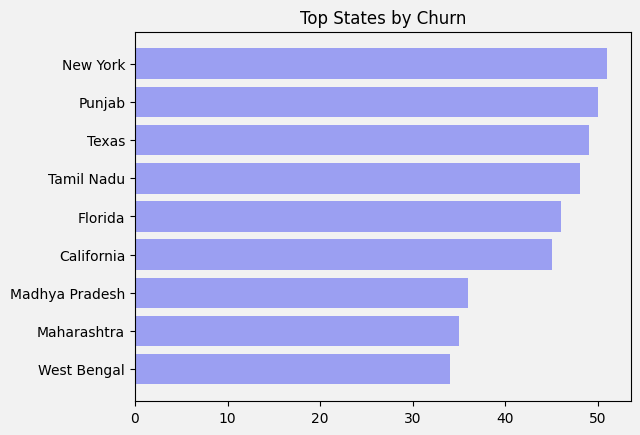

In [6]:
s = churn_by_state(df).head(10)
plt.barh(s["State"], s["Churned_Customers"], color=SECONDARY)
plt.title("Top States by Churn")
plt.gca().invert_yaxis()
plt.show()

## Churn by Payment Method & Contract

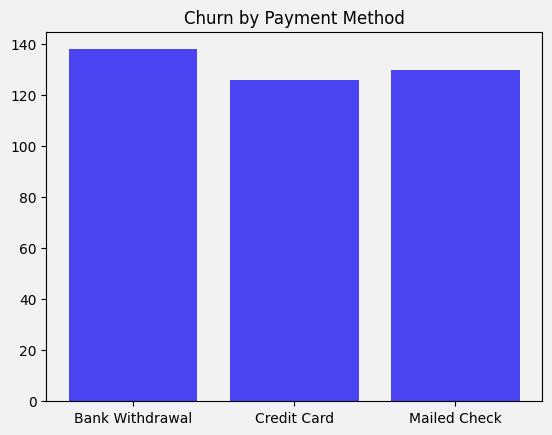

In [7]:
p = churn_by_payment_method(df)
plt.bar(p["Payment_Method"], p["Churned_Customers"], color=PRIMARY)
plt.title("Churn by Payment Method")
plt.show()

## Churn by Tenure

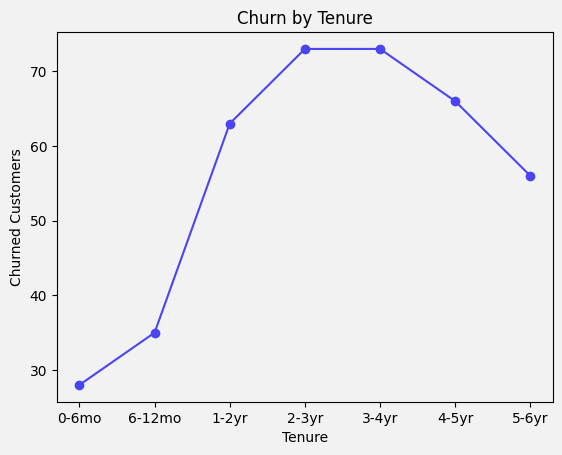

In [8]:
t = churn_by_tenure_band(df)
plt.plot(t["Tenure_Band"].astype(str), t["Churned_Customers"], marker="o", color=PRIMARY)
plt.title("Churn by Tenure")
plt.xlabel("Tenure"); plt.ylabel("Churned Customers")
plt.show()

## Churn Distribution (Category)

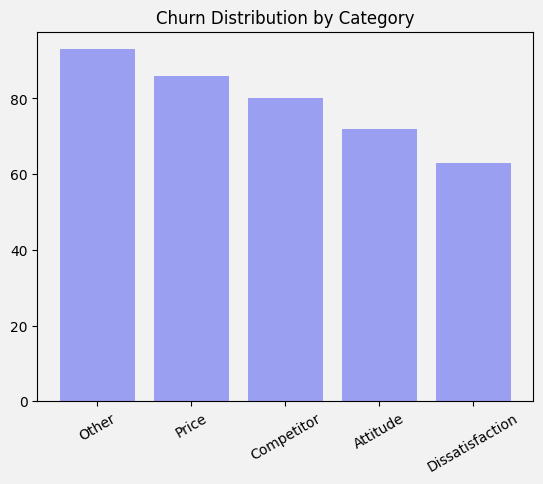

In [9]:
cd = churn_distribution(df)
plt.bar(cd["Churn_Category"], cd["Churned_Customers"], color=SECONDARY)
plt.title("Churn Distribution by Category")
plt.xticks(rotation=30)
plt.show()

## Services Summary

In [10]:
services_summary(df)

,Phone_Service,Multiple_Lines
Yes,1808,681
No,192,637
